In [1]:
file_read = "001_refit"
file_write = "004_feature_correlation"

# 0. Correlation of all features

In [2]:
import polars as pl

df = pl.read_parquet("../../dataset.parquet")

In [3]:
columns_feat = [column for column in df.columns if "zero" in column]

In [4]:
df_corr = df[columns_feat].corr()
data = df_corr.to_numpy()

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(28, 28), dpi=300)

im = ax.imshow(data, vmin=-1, vmax=1, cmap="bwr")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Intermediate")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat])
ax.set_yticklabels([c[:-5] for c in columns_feat])

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = round(data[i, j], 2)
        color = "white" if val <= -0.3 else "black"
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=color
        )

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
#plt.show()
plt.close(fig)

# 1. Correlation of features selected by RFE

In [6]:
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [7]:
n_features = 11

In [8]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features)

for column in df_coefs_.columns:
    if df_coefs_[column].is_null().all():
        df_coefs_ = df_coefs_.drop(column)

columns_feat_ = [column for column in df_coefs_.columns if "zero" in column]

In [9]:
columns_feat_

['7_zero',
 '91_zero',
 '232_zero',
 '234_zero',
 '235_zero',
 '240_zero',
 '271_zero',
 '324_zero',
 '469_zero',
 '494_zero',
 '543_zero']

In [10]:
df_corr_ = df[columns_feat_].corr()
data_ = df_corr_.to_numpy()

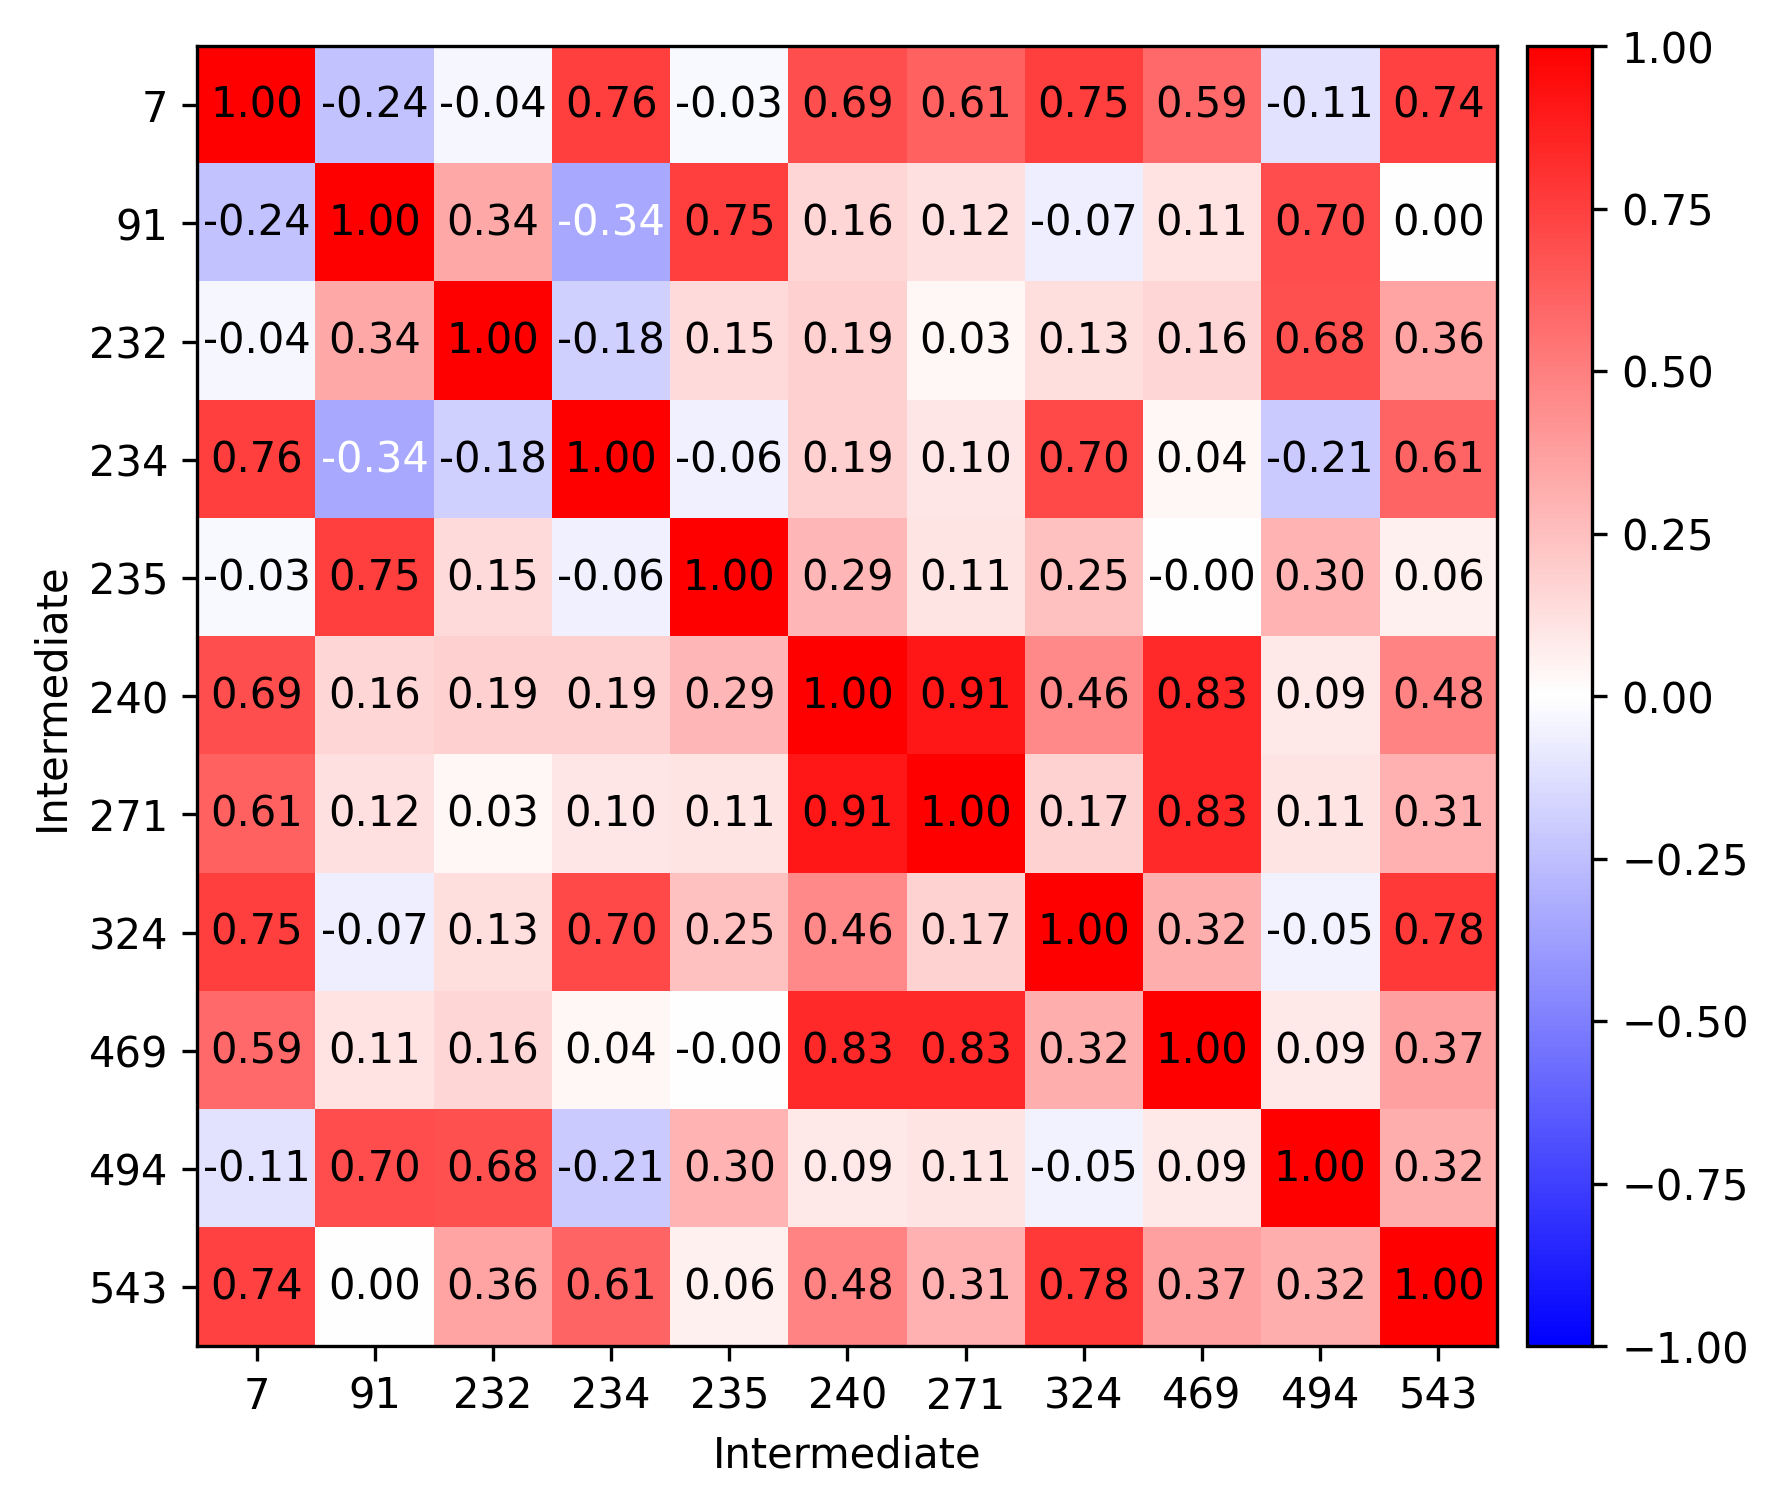

In [11]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

im = ax.imshow(data_, vmin=-1, vmax=1, cmap="bwr")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Intermediate")
ax.set_xticks(np.arange(data_.shape[1]))
ax.set_yticks(np.arange(data_.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat_])
ax.set_yticklabels([c[:-5] for c in columns_feat_])

for i in range(data_.shape[0]):
    for j in range(data_.shape[1]):
        val = round(data_[i, j], 2)
        color = "white" if val <= -0.3 else "black"
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=color
        )

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_selected.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

# 2. Correlation vs. number of features

In [12]:
corrs = {}

for n_features in df_coefs["n_features"]:
    df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features)
    
    for column in df_coefs_.columns:
        if df_coefs_[column].is_null().all():
            df_coefs_ = df_coefs_.drop(column)
            
    columns_feat_ = [column for column in df_coefs_.columns if "zero" in column]
    data_ = df[columns_feat_].corr().to_numpy()
    num_ = data_.shape[0]
    corrs[n_features] = (np.sum(np.abs(data_)) - num_) / (num_ ** 2 - num_)

In [13]:
corrs

{51: 0.37964017456050475,
 50: 0.3746432032374871,
 49: 0.37749105279825274,
 48: 0.3748571177552347,
 47: 0.3725537570602121,
 46: 0.3706979656771198,
 45: 0.36549606662965206,
 44: 0.36797668530709693,
 43: 0.36639742423578686,
 42: 0.3629689198739901,
 41: 0.35759907915282674,
 40: 0.35447999410297204,
 39: 0.3609054263377024,
 38: 0.36685830665928953,
 37: 0.36443483010574007,
 36: 0.35962175598742707,
 35: 0.3581968934024327,
 34: 0.3575121215403621,
 33: 0.3519289207617801,
 32: 0.3651977437469323,
 31: 0.36034977173753574,
 30: 0.3610614864162433,
 29: 0.3638058836302293,
 28: 0.3686469145569492,
 27: 0.36021457831069176,
 26: 0.3529831407580227,
 25: 0.3426439267781515,
 24: 0.34092516360882186,
 23: 0.35173693702245895,
 22: 0.3433200679929626,
 21: 0.3475111964797295,
 20: 0.34817224903515653,
 19: 0.3527427727604178,
 18: 0.35703527600385687,
 17: 0.37017015389462443,
 16: 0.36882560493742006,
 15: 0.3593199732848041,
 14: 0.33917491985816045,
 13: 0.37050550676461275,
 12: 

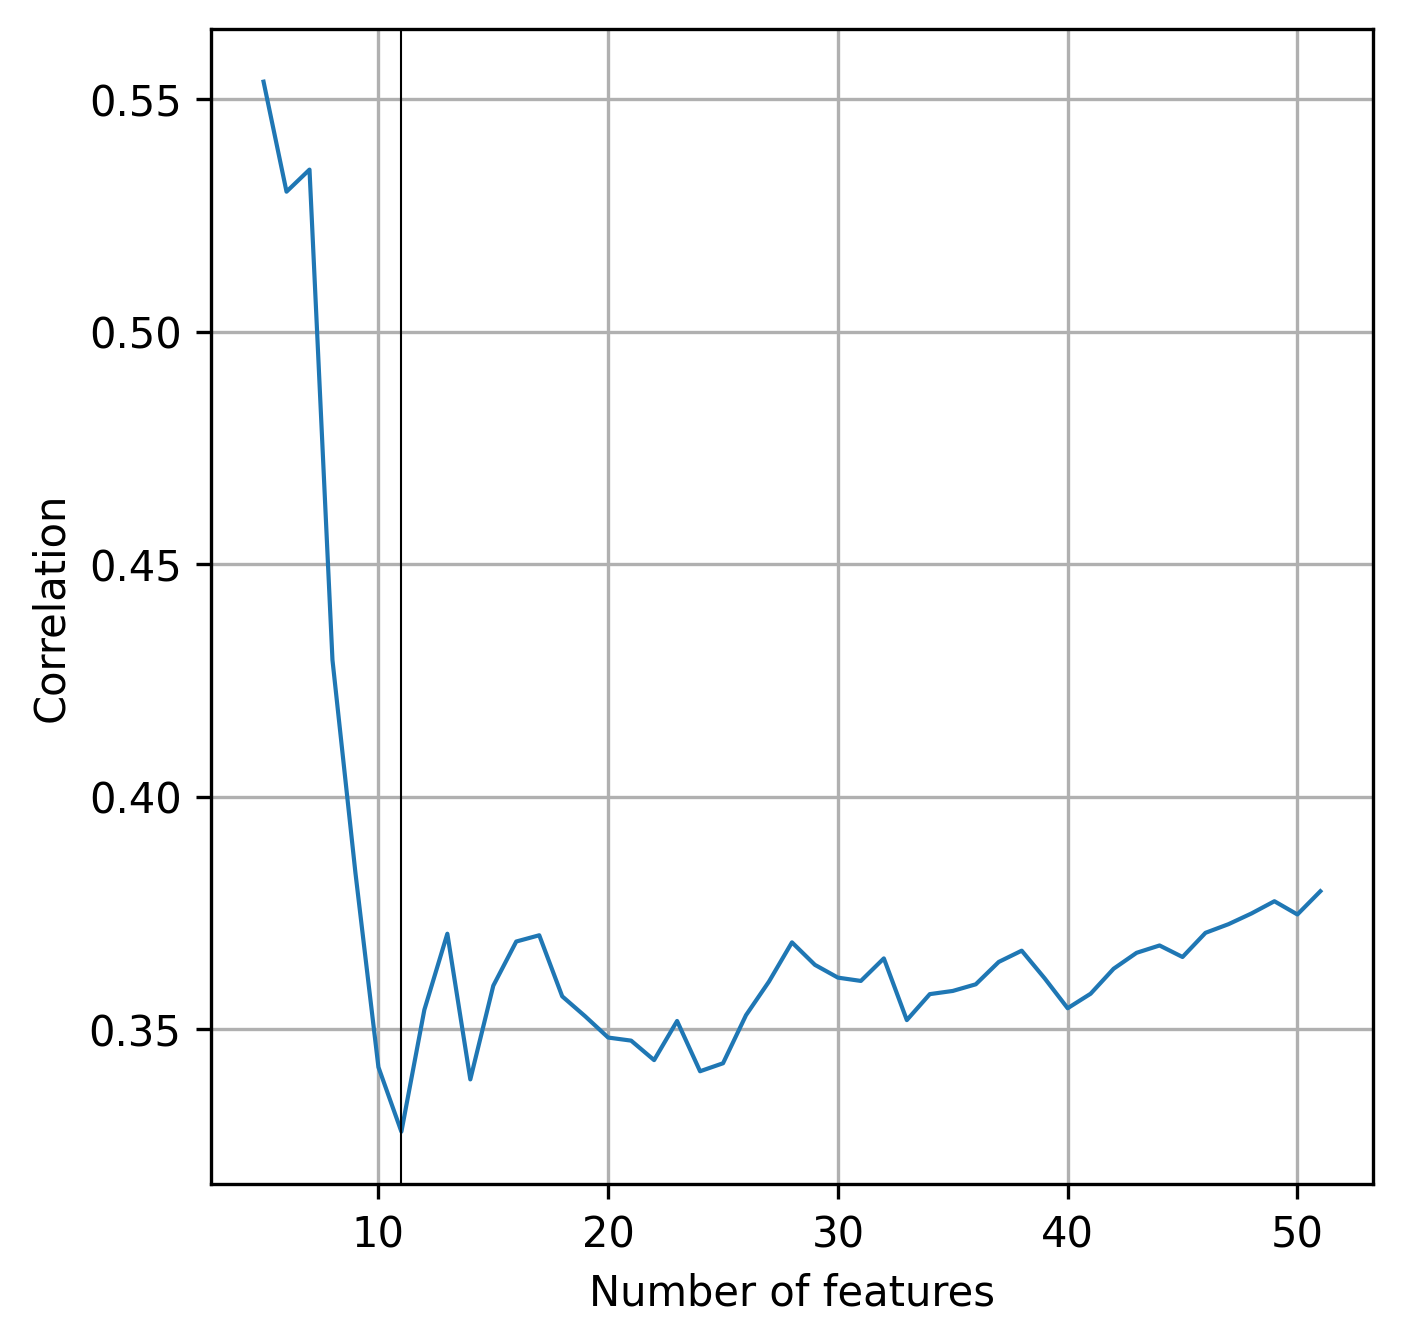

In [14]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(corrs.keys(), corrs.values(), linewidth=1)
ax.axvline(11, color="black", linewidth=0.5)

ax.set_xlabel("Number of features")
ax.set_ylabel("Correlation")

ax.grid()

plt.savefig(
    f"{file_write}_RFE.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()